# Introduction

In this lab, we will apply some of the techniques we used last week to model multi-dimensional motion. Along the way, you'll learn some additional techniques for modeling physics problems in Python.


Recall that the equation for graviational force on object 2 due to object 1 is

$\vec{F}_{\textrm{on 2}}=G\frac{m_{1}m_{2}}{|\vec{r}|^{2}}\hat{r}$ with $\vec{r}=\vec{r}_{2}-\vec{r}_1$.

Unlike last week, here we have an example of a force that changes with position.
Our goal is model the  motion of the spacecraft and test how different starting conditions can impact the orbit (or lack thereof). In this case, we'll be drawing our orbits out.

This really isn't much different than making a typical plot. We're going to use the


To get you started, I've included some code to make a plot that draws a blue sphere to represent the Earth.

In these lab you'll


1.   Learn one way to make 2D vectors for

2.   Use a loop to approximate the orbit of the spacecraft.

3.   Use the momentum principal in the modeling

4.   Make an animated plot of the simulation.


# Setting the scene

First we create a figure in which to plot


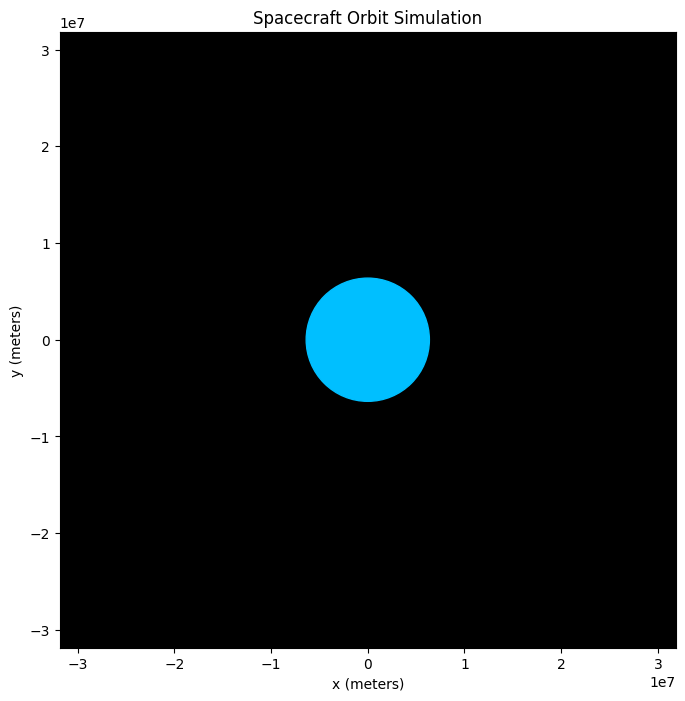

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation #this allows us to make the plot into an animation
from IPython.display import HTML #this allows us to run an animation in colab
REarth = 6.371e6   # Radius of Earth (meters)
earth_pos = np.array([0.0, 0.0])
# Set up the plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')
ax.set_facecolor('black') # Black background

# Set plot limits based on the initial position to keep the view consistent
plot_limit = 5 * REarth
ax.set_xlim(-plot_limit, plot_limit)
ax.set_ylim(-plot_limit, plot_limit)
plt.title('Spacecraft Orbit Simulation')
ax.set_xlabel('x (meters)')
ax.set_ylabel('y (meters)')


# Draw the Earth as a blue circle
earth_circle = plt.Circle(earth_pos, REarth, color='deepskyblue', zorder=5)
ax.add_patch(earth_circle)

# Initialize the spacecraft and its trail
# The spacecraft is a small magenta dot (the 'point')
# Its path is a line that will be updated each frame (the 'trail')
point, = ax.plot([], [], 'o', color='magenta', markersize=6, zorder=10)
trail, = ax.plot([], [], '-', color='orchid', alpha=0.7, zorder=8)



Here is what each line means:



```
fig
```
makes a window to hold the plot.

```
ax
```
creates the axes region. By convection it is often called "ax".

Here we provide some formatting details about our plot. For example, we can make the background black, to make it look like "outer space":

```
ax.set_aspect('equal')
ax.set_facecolor('black') # black background
```



Next we set up our plot. We are going to be plotting something orbiting the Earth, so we set our x and y limits so that we can see the Earth and the object rotating it. We also follow good plotting convenction by giving titles and labels to our plot and axes.

```
# Set plot limits based on the initial position to keep the view consistent
plot_limit = 5 * REarth
plotplot.set_xlim(-plot_limit, plot_limit)
plotplot.set_ylim(-plot_limit, plot_limit)
plt.title('Spacecraft Orbit Simulation')
plotplot.set_xlabel('x (meters)')
plotplot.set_ylabel('y (meters)')
```

Next we do some clever plotting to illustrate our scene. There are some other approaches you can take to this problem but working within matplotlib, this is one simpler approach.

We draw Earth as a big blue dot and the spacecraft as smaller magneta dot. We also add the plotting of a trail so we see the path of the spacecraft.
Because we have everything scaled, we can make the size of the Earth the radius of the Earth and place it at our earth_pos (best option is to center it). If you are curious about some of the other options I used, I encourage you to go look at the matplotlib documentation. I'm encouraging you to do that, rather than telling you what they mean, so that you gain practice looking through documentation.

```


# Draw the Earth as a blue circle
earth_circle = plt.Circle(earth_pos, REarth, color='deepskyblue', zorder=5)
plotplot.add_patch(earth_circle)

# Initialize the spacecraft and its trail
# The spacecraft is a small magenta dot (the 'point')
# Its path is a line that will be updated each frame (the 'trail')
point, = plotplot.plot([], [], 'o', color='magenta', markersize=6, zorder=10)
trail, = plotplot.plot([], [], '-', color='orchid', alpha=0.7, zorder=8)

```




## The actual simulation

So we are going to be simulating a spacecraft orbiting Earth.

The first thing I want you to do sketch out an algorithm you'll follow.

You don't have to put these in the lab report.

1.  What constants and variables do you need?
2.  If you choose to make a loop, what goes in the loop?
3. What calculations will you be making?


I've setup a skeleton core here, that includes the plotting I shared before.

Choose a reasonable mass for your spacecraft.

We will be storing our positions for plotting in [x,y] using NumPy arrays. Like this one, that you've already seen above.



```
earth_pos = np.array([0.0, 0.0])
```

Something tricky that we haven't talked about in class is circular motion. If our orbit is going to be stable we need to consider what the minimum velocity should be if it's not going to fall into the Earth. We can do this by

$F_{g}=F_{c}$

where
${F}_{g}=G\frac{m_{1}m_{2}}{|\vec{r}|^{2}}$
and
$F_{g}=m_{1}\frac{v^{2}}{r}$
Note that in Python powers are done using ** so

$x^{2}$ is
```
x**2
```

Note that for our position storage we need to initalize the vector. We can do something like the below, where I added the print function so you can seee what it looks like.


In [ ]:
nsteps=10
a=np.zeros((nsteps,2))
print(a)

[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


Hint: Ask your self, for the loop:

"In what order should I update variables?"

"What does the graviational force depend on?"

At the end of the code space I give you a function that runs the animation.



```
def animate(frame):
    # Update the spacecraft's position.
    # The set_data method expects a sequence (like a list or array).
    # We provide the single x and y coordinates for the current frame inside lists.
    point.set_data([positions[frame, 0]], [positions[frame, 1]])

    # Update the trail to show the path so far
    trail.set_data(positions[:frame+1, 0], positions[:frame+1, 1])

    return point, trail
```

What is happening here is that the animation function from matplotlib FuncAnimation() expects a function that tells it what to update in the plot.

FuncAnimation will pass an increasing number for "frame".  
```
positions[frame,0]
```
gets us the x position
```
positions[frame,1]
```
gets us the y position

then it moves the point to that location

For the trail it is a little different.
```
positions[:frame+1,0]
```
takes all the x positions from the start to the current frame. (and likewise for y).

then set_data will draw a line along the past points.

We only return point and trail because that is what is updated

Then in
```
anim = FuncAnimation(fig, animate, frames=num_steps // 50, interval=40, blit=True)
```
We specify where the animation is happening (our figure "fig")

Then we give it the update function we made, "animate", which is run for each frame.

Then we say how many frames there should be. // is a way of doing division to out put an integer. Doing 50//num_steps means we don't show every step, which makes the process much faster.

Interval=40 is the speed in milliseconds.

blit=True tells matplotlib to only redraw parts of the plot that have changed, rather than the whole thing (like Earth).

In [ ]:
 #Gravitational Orbit Simulation
#Import libraries

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


# --- 1. SETUP: CONSTANTS AND INITIAL CONDITIONS ---

# Physical Constants and initial conditions
# What constants do you need? ASK FOR HELP IF NEEDED
G = 6.67e-11
me = 5.972e24
re = 6.371e6
ms = 1.2e5
# Simulation Parameters


deltat = 60    # Time step in seconds (1 minute)
total_time = 24*60*60*3   # Total simulation time (e.g., 12 hours)
num_steps = total_time // deltat # fill in yourself

# Initial State of the System

# We use NumPy arrays for vector quantities. A 2D vector [x, y] is used for simplicity.
earth_pos = np.array([0.0, 0.0])
craft_initial_pos = np.array([1.0e7, 0.0])


#We need to consider what the inital velocity should be.


# To achieve a stable orbit, the spacecraft needs an initial velocity.
# If starting with zero velocity, it would fall directly into Earth.
# Let's calculate the velocity for a circular orbit: v = sqrt(G * M / r)
r_initial = np.linalg.norm(craft_initial_pos) # This is a hint for you. We are getting the initial distance using our initial position and the norm function we used in class.
v_circular_mag = np.sqrt(G*me/r_initial)# Write a calculation for this
craft_initial_vel = np.array([0.0, v_circular_mag])# Make an inital velocity vector. Keep in mind, circular velocity is perpendicular to the position vector

# Calculate initial momentum
craft_initial_p = ms*craft_initial_vel # do this yourself

# ---2. CALCULATING THE TRAJECTORY ---
# We will pre-calculate the entire trajectory of the spacecraft. Note the animation function
# only needs to read the data, not compute it on the fly.

# Create arrays to store the results at each time step
#remember we can use
positions = np.empty(shape = (num_steps, 2))#make your empty array
positions[0] = craft_initial_pos
#set the inital position the starting position.
#set the momentum to the starting momentum
#make a loop to fill our array. I'll show you since we haven't done a lot of this yet.
p = np.empty(shape = (num_steps, 2))
p[0] = craft_initial_p
for i in range(1, num_steps):
    #now we implement the momentum principal.
    r_current = np.linalg.norm(positions[i-1])
    Fg_mag = (G*me*ms)/(r_current**2)
    Fx = -(Fg_mag/r_current)*positions[i-1, 0]
    Fy = -(Fg_mag/r_current)*positions[i-1, 1]

    p[i, 0] = p[i-1, 0] + (Fx*deltat)
    p[i, 1] = p[i-1, 1] + (Fy*deltat)
    positions[i, 0] = positions[i-1, 0] + (p[i, 0]/ms)*deltat
    positions[i, 1] = positions[i-1, 1] + (p[i, 1]/ms)*deltat


# --- 3. VISUALIZATION: ANIMATING THE ORBIT ---

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')
ax.set_facecolor('black') # Black background

# Set plot limits based on the initial position to keep the view consistent
plot_limit = 5 * re
ax.set_xlim(-plot_limit, plot_limit)
ax.set_ylim(-plot_limit, plot_limit)
plt.title('Spacecraft Orbit Simulation')
ax.set_xlabel('x (meters)')
ax.set_ylabel('y (meters)')


# Draw the Earth as a blue circle
earth_circle = plt.Circle(earth_pos, re, color='deepskyblue', zorder=5)
ax.add_patch(earth_circle)

# Initialize the spacecraft and its trail
# The spacecraft is a small magenta dot (the 'point')
# Its path is a line that will be updated each frame (the 'trail')
point, = ax.plot([], [], 'o', color='magenta', markersize=6, zorder=10)
trail, = ax.plot([], [], '-', color='orchid', alpha=0.7, zorder=8)


# Animation update function. This is called for each frame.
def animate(frame):
    # Update the spacecraft's position.
    # The set_data method expects a sequence (like a list or array).
    # We provide the single x and y coordinates for the current frame inside lists.
    point.set_data([positions[frame, 0]], [positions[frame, 1]])

    # Update the trail to show the path so far
    trail.set_data(positions[:frame+1, 0], positions[:frame+1, 1])

    return point, trail

# Create the animation
# We speed up the animation by skipping frames. frames=num_steps//50 means we'll
# show every 50th calculated position. The interval is the delay between frames in ms.
anim = FuncAnimation(fig, animate, frames=num_steps // 50, interval=40, blit=True)


# --- 4. DISPLAY IN COLAB ---
# To display the animation in a Colab or Jupyter notebook, you need to
# convert it to a format the browser can understand, like HTML5 video or JSHTML.

HTML(anim.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

# Questions for the lab


1. What velocity did you use? How did you determine it?
2.  Change the time step to so that is 10 times larger? How does this impact the shape and stability of the orbit?
3.   What happens if you lower the velocity?
4.   Make the spacecraft escape the orbit. What did you need to do?
5.   What would you need to do if we had to include other bodies, like the Moon and the Sun? DON'T DO THIS FOR THIS LAB.


